In [ ]:
import interpolator.util as util
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import corner
import os

folder_path = os.path.dirname('C:/Users/mikel/Desktop/5000_runs/')

param_names = ['id', 'log_lsun', 't_exp', 'v_start', 'X', 'Z']
limits = [(7.32, 9.12), (11, 15), (5800, 7000), (0.3, 0.8), (5e-4, 5e-2)]
X_indexed, y, wav_mod = util.read_grid_runs(folder_path, param_names)
X = X_indexed.drop('id', axis=1)
grid = pd.read_csv(os.path.join(folder_path, 'grid.csv'))

ran_i = X_indexed['id'].to_numpy(int)
grid_i = grid['id'].to_numpy(int)
failed_i = np.array([x for x in grid_i if x not in ran_i])
failed_mask = np.array([x in failed_i for x in grid['id']])
X_failed = grid[failed_mask][param_names].drop('id', axis=1)

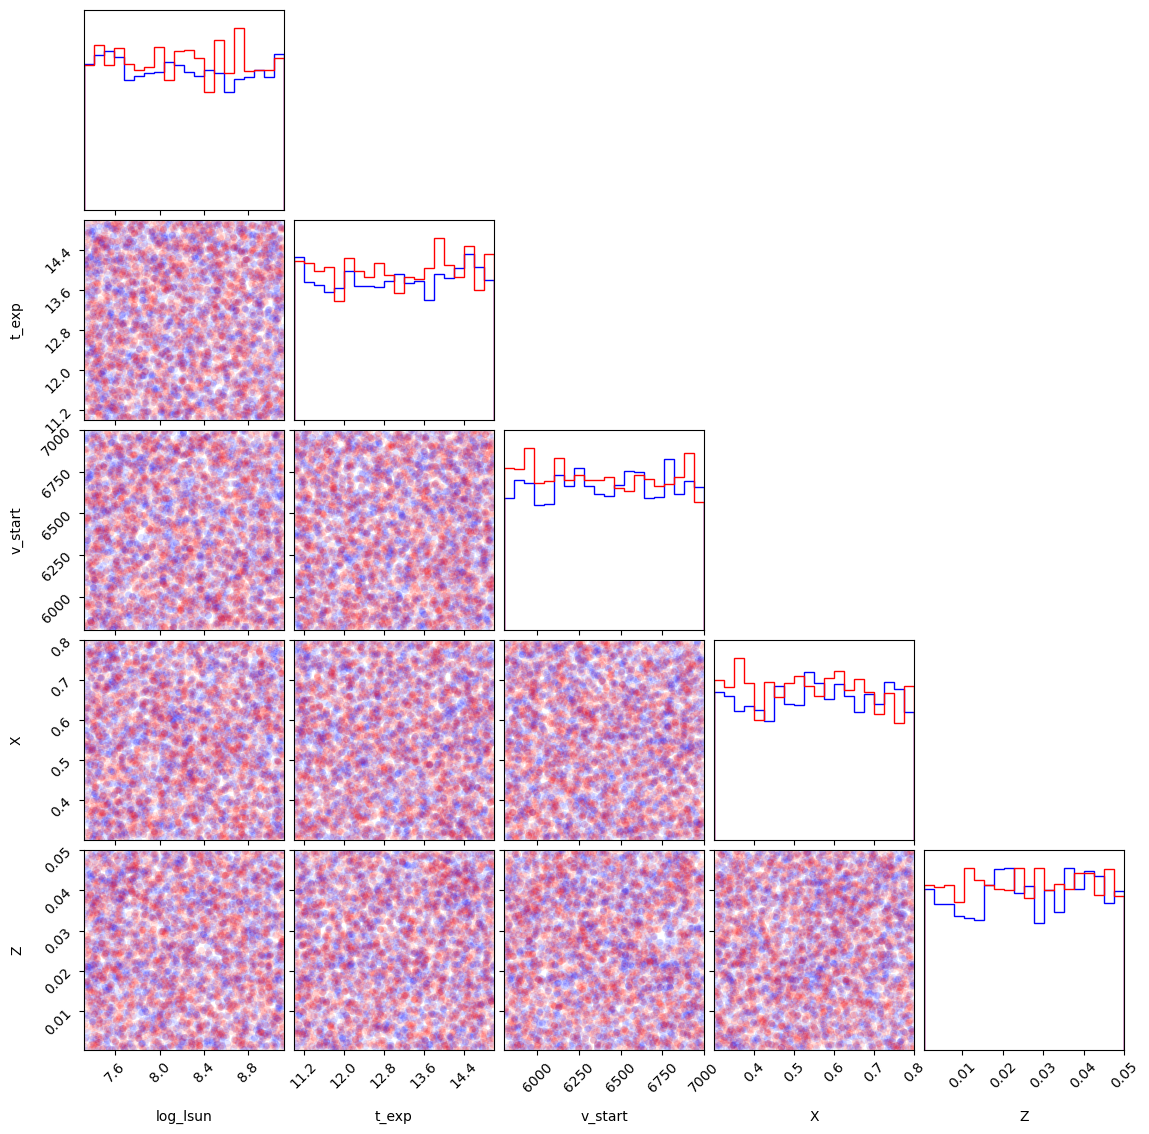

In [28]:
# Plot successful
fig = corner.corner(
    X.values,
    labels=X.columns,
    range=limits,
    bins = 20,
    color='blue',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

# Plot failed
corner.corner(
    X_failed.values,
    fig=fig,
    labels=X.columns,
    range=limits,
    bins = 20,
    color='red',
    plot_contours=False,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'ms': 5}
)

plt.show()

In [ ]:
# Create new grid with failed points
new_grid = grid[failed_mask]
new_grid.to_csv('grid.csv', index=False)

In [ ]:
# Rename spectra using proper indices
import json

folder = os.path.dirname('C:/Users/mikel/Desktop/5000_runs_2/')
params = pd.read_json(os.path.join(folder, 'parameters.log'), lines=True)
grid = pd.read_csv(os.path.join(folder, 'grid.csv'))

for index in range(len(params)):
    row = params.iloc[index]
    id = grid.iloc[index]['id'] # This is the true ID

    # First rename to temp so there's no overrides
    old_path = os.path.join(folder, str(index) + '_sed.csv')
    new_path = os.path.join(folder, str(index) + '_temp_sed.csv')
    os.rename(old_path, new_path)

    # Final rename
    # old_path = os.path.join(folder, str(index) + '_temp_sed.csv')
    # new_path = os.path.join(folder, str(id) + '__sed.csv')
    # os.rename(old_path, new_path)

# params_path = os.path.join(folder, 'parameters_new.log')
# with open(params_path, 'a') as file:
#     json.dump(params, file)

# for i, row in enumerate(params.rows):
#     print(row)
#     break

# SED names are the indices of each grid.csv line, so change the ID in the parameters.log entry and the SED name to the ID in grid.csv

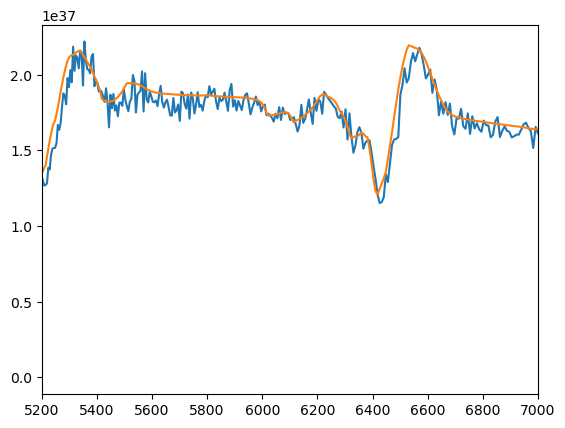

In [36]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

folder = os.path.dirname('C:/Users/mikel/Desktop/10000_runs/')
params = pd.read_json(os.path.join(folder, 'parameters.log'), lines=True)
index = np.random.randint(0, len(params))
id = params.iloc[index]['id']

df = pd.read_csv(os.path.join(folder, str(id) + '_virtual_sed.csv'))
plt.plot(df['wavelength'], df['L_density'])
df = pd.read_csv(os.path.join(folder, str(id) + '_integrated_sed.csv'))
plt.plot(df['wavelength'], df['L_density'])
plt.xlim(5200, 7000)
plt.show()